# CML subsample representativeness — is a contiguous $M$-window faithful to the full-lattice regime?

**Why this matters.** The SPI-SPI pipeline observes a contiguous $M$-channel window cropped from a
`max(M,100)`-site CML lattice and reduces it to $f_{ij}=\mathrm{corr}(\text{SPI}_i,\text{SPI}_j)$.
Two things must hold for the embedding to work: the window must be (a) *discriminative* of the regime and
(b) *representative* of it across $M$ (so the same regime at different $M$ co-locates — the dimension-invariance
novelty). The worry: some regimes (e.g. Brownian-defect) carry their dynamics on a **small, moving** spatial
support, so a fixed contiguous window might miss them.

This notebook tests the **representativeness** half mechanistically with cheap spatial/temporal features
(structure factor, correlation length, temporal PSD) on a large $L=200$ ground-truth lattice vs $M\in\{8,16,32\}$
windows. It is a **conservative necessary condition**: these cheap features resolve *fewer* regimes than the
187-D SPI features, so *representative here* ⇒ *representative under SPI-SPI*. The discrimination half is measured
directly on real SPI features in `cml_regime_separability.ipynb`.

**Result (see figure below).**
- Spatial correlation length $\xi \approx 1\text{–}4$ sites for **all six** chosen regimes — a contiguous
  $M\ge 8$ window spans many $\xi$, so bulk pairwise statistics are representative. $\xi$: frozen 2, brownian 1,
  defect-turb 1, sti-i 3, fdstc 2, traveling-wave 4.
- Window→full temporal-PSD divergence falls monotonically with $M$ (M=8 is the noisy stress corner; M=16/32 clean).
- Brownian-defect is **not** an outlier: over $T$ the wandering defect ergodically visits the window, so the
  time-averaged window statistics are spatially stationary (confirmed by the instance-dispersion cell, which is
  ~$T$-insensitive down to $T=500$).

![representativeness](graphics/cml_subsample_representativeness.png)

We keep a **fixed large lattice** (not `lattice=M`): an $M$-site lattice would be a *different* finite-size system
(the Kaneko phases are large-$N$) and would break the dimension-invariance claim, which needs one fixed process
observed at varying $M$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.generators.dynamical import generate_cml_logistic

REGIMES = {  # the 6 chosen for configs/generate/embeddings/cml-embedding.yaml
    "frozen-chaos":      dict(alpha=1.45,   eps=0.2),
    "brownian-defect":   dict(alpha=1.85,   eps=0.1),
    "defect-turbulence": dict(alpha=1.895,  eps=0.1),
    "sti-i":             dict(alpha=1.7522, eps=0.00115),
    "fdstc":             dict(alpha=2.0,    eps=0.3),
    "traveling-wave":    dict(alpha=1.47,   eps=0.5),
}
L, T, TRANS = 200, 1500, 2000
Ms = [8, 16, 32]

def sim(p, T=T, L=L, seed=0):
    return generate_cml_logistic(M=L, T=T, transients=TRANS, sample_every=1,
                                 zscore=False, rng=np.random.default_rng(seed), **p)

def structure_factor(U):
    X = U - U.mean(1, keepdims=True)
    return (np.abs(np.fft.rfft(X, axis=1))**2).mean(0)

def spatial_autocorr(U):
    X = U - U.mean(1, keepdims=True); Lx = X.shape[1]
    P = np.abs(np.fft.rfft(X, axis=1))**2
    ac = np.fft.irfft(P, n=Lx, axis=1).mean(0); return ac/ac[0]

def corr_length(U):
    ac = spatial_autocorr(U); b = np.where(ac[:len(ac)//2] < 1/np.e)[0]
    return float(b[0]) if len(b) else float(len(ac)//2)

def temporal_psd(U):
    X = U - U.mean(0, keepdims=True)
    P = (np.abs(np.fft.rfft(X, axis=0))**2).mean(1); s = P.sum()
    return P/s if s>0 else P

def js(p, q):
    p, q = p/p.sum(), q/q.sum(); m = 0.5*(p+q)
    kl = lambda a, b: np.sum(a[a>0]*np.log(a[a>0]/b[a>0]))
    return float(np.sqrt(0.5*kl(p,m)+0.5*kl(q,m)))

## 1. Full-lattice ground truth: structure factor, correlation length, window→full convergence

regime             xi(1/e)  dPSD@M8  dPSD@M16  dPSD@M32
frozen-chaos         2.0     0.034    0.026    0.019
brownian-defect      1.0     0.168    0.135    0.081
defect-turbulence    1.0     0.244    0.180    0.128
sti-i                3.0     0.236    0.124    0.078
fdstc                2.0     0.164    0.115    0.079
traveling-wave       4.0     0.074    0.066    0.047


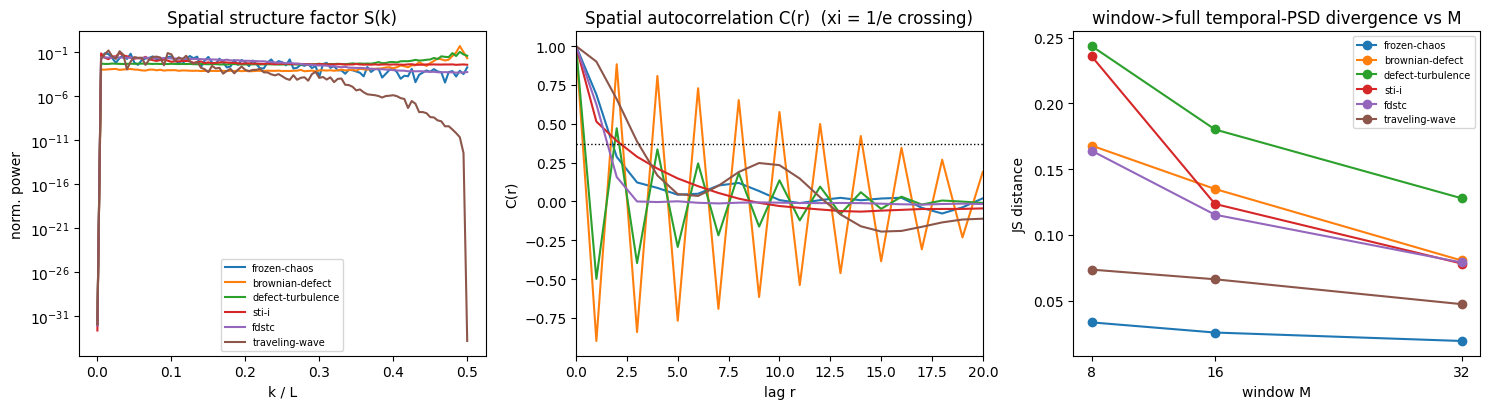

In [2]:
full = {n: sim(p) for n, p in REGIMES.items()}
xi   = {n: corr_length(U) for n, U in full.items()}
psd_full = {n: temporal_psd(U) for n, U in full.items()}

conv = {n: [] for n in REGIMES}
for n, U in full.items():
    for M in Ms:
        offs = range(0, L-M+1, max(1, (L-M)//12))
        conv[n].append(np.mean([js(temporal_psd(U[:, o:o+M]), psd_full[n]) for o in offs]))

print(f"{'regime':18s} xi(1/e)  " + "  ".join(f"dPSD@M{m}" for m in Ms))
for n in REGIMES:
    print(f"{n:18s} {xi[n]:5.1f}   " + "  ".join(f"{c:7.3f}" for c in conv[n]))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2)); cmap = plt.cm.tab10
for i, (n, U) in enumerate(full.items()):
    c = cmap(i); Sk = structure_factor(U)
    ax[0].semilogy(np.arange(len(Sk))/L, Sk/Sk.sum(), color=c, label=n)
    ax[1].plot(spatial_autocorr(U)[:L//4], color=c)
    ax[2].plot(Ms, conv[n], "o-", color=c, label=n)
ax[0].set(title="Spatial structure factor S(k)", xlabel="k / L", ylabel="norm. power"); ax[0].legend(fontsize=7)
ax[1].axhline(1/np.e, ls=":", c="k", lw=1); ax[1].set_xlim(0, 20)
ax[1].set(title="Spatial autocorrelation C(r)  (xi = 1/e crossing)", xlabel="lag r", ylabel="C(r)")
ax[2].set(title="window->full temporal-PSD divergence vs M", xlabel="window M", ylabel="JS distance")
ax[2].set_xticks(Ms); ax[2].legend(fontsize=7)
fig.tight_layout(); plt.show()

## 2. Instance-dispersion & $T$-sensitivity (the real SPI-SPI setting)

Each SPI-SPI sample is **one** $M\times T$ realization. The relevant quantity is therefore how much a cheap-feature
profile varies *across independent instances* at fixed $(M,T)$, vs the gap to the nearest regime. Low + $T$-stable
dispersion ⇒ the window is a reliable fingerprint. The Brownian-defect worry would show up here as exploding
dispersion at short $T$ (defect stuck in/out of window) — it does **not**.

In [3]:
from itertools import combinations
def feat(W):
    P = temporal_psd(W); nb = 16
    bins = np.array([P[i*len(P)//nb:(i+1)*len(P)//nb].sum() for i in range(nb)])
    return np.concatenate([bins, [np.log(W.var()+1e-9), corr_length(W)/W.shape[1]]])
def dispersion(F):
    Fn = F/(np.linalg.norm(F, axis=1, keepdims=True)+1e-12); S = Fn@Fn.T
    iu = np.triu_indices(len(F), 1); return float((1-S[iu]).mean())

N, M = 15, 16
for Tt in (500, 2000):
    cents, disp = {}, {}
    for n, p in REGIMES.items():
        off = (L-M)//2
        F = np.array([feat(sim(p, T=Tt, seed=1000+i)[:, off:off+M]) for i in range(N)])
        cents[n], disp[n] = F.mean(0), dispersion(F)
    names = list(REGIMES); C = np.array([cents[n] for n in names])
    Cn = C/np.linalg.norm(C, axis=1, keepdims=True); B = 1 - Cn@Cn.T
    print(f"--- T={Tt}  within-regime instance dispersion vs nearest-regime gap (cheap features)")
    for i, n in enumerate(names):
        nn = np.argsort(B[i]); gap, near = B[i][nn[1]], names[nn[1]]
        print(f"  {n:18s} within={disp[n]:.4f}  gap={gap:.4f} -> {near}")

--- T=500  within-regime instance dispersion vs nearest-regime gap (cheap features)
  frozen-chaos       within=0.0008  gap=0.0010 -> traveling-wave
  brownian-defect    within=0.0003  gap=0.0020 -> traveling-wave
  defect-turbulence  within=0.0045  gap=0.0051 -> brownian-defect
  sti-i              within=0.0074  gap=0.2619 -> fdstc
  fdstc              within=0.0008  gap=0.0380 -> defect-turbulence
  traveling-wave     within=0.0014  gap=0.0010 -> frozen-chaos
--- T=2000  within-regime instance dispersion vs nearest-regime gap (cheap features)
  frozen-chaos       within=0.0008  gap=0.0011 -> traveling-wave
  brownian-defect    within=0.0002  gap=0.0020 -> traveling-wave
  defect-turbulence  within=0.0008  gap=0.0085 -> brownian-defect
  sti-i              within=0.0088  gap=0.2759 -> fdstc
  fdstc              within=0.0002  gap=0.0326 -> defect-turbulence
  traveling-wave     within=0.0013  gap=0.0011 -> frozen-chaos


## Caveats
- **Cheap features are conservative.** They blur frozen↔traveling-wave and brownian↔defect-turbulence — pairs the
  187-D SPI features resolve cleanly (5-fold 5-NN recall 0.98 / 0.96 on the existing `data/embeddings/cml-small`
  run). So the cheap-feature gaps **understate** real SPI-SPI separability; treat section 2 as a representativeness
  floor, not the discrimination result.
- **Discrimination** is measured on real SPI features in `cml_regime_separability.ipynb` and the pooled screen
  (fdstc 1.00, frozen 0.98, defect-turb 0.96, brownian 0.89, sti-i 0.87; traveling-wave variants merge).
- **M=8** is the stress corner: only $\binom{8}{2}=28$ channel-pairs ⇒ noisiest $f_{ij}$, and $\xi$ up to 4 leaves
  ~2 correlation lengths. It is kept deliberately as the dimension-invariance stress-test; M=16/32 are the anchors.